# Programa de Ciencia de Datos

Mi Primer Machine Learning
Jose Alejandro Alfaro Arias

## 1. Acceso a los datos

In [20]:
# Librerías básicas
import numpy as np # Sirve para operaciones matemáticas como: np.sqrt(), np.square(), np.mean(), np.std()
import pandas as pd # Sirve para manejar datos de estructuras tabulares llamadas Dataframe
import matplotlib.pyplot as plt # Sirve para construir gráficos
import seaborn as sns # Sirve para visualización y está construida sobre Matplotlib

## 1.2 Carga del Dataset y Separación para conjunto de entrenamiento

In [21]:
datatrain = pd.read_csv('/content/sample_data/california_housing_train.csv', sep = ",") # Se carga el dataset
datatrain.sample(5) # Monstrar datos e inspeccionarlos


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
9665,-119.53,36.55,34.0,2065.0,343.0,1041.0,313.0,3.2917,111500.0
5469,-118.16,33.94,25.0,5675.0,1224.0,3317.0,1119.0,3.9352,232900.0
5290,-118.14,33.90,26.0,2145.0,471.0,1150.0,429.0,3.5972,225800.0
6580,-118.28,34.05,44.0,1273.0,474.0,1754.0,460.0,1.6037,275000.0
14466,-122.13,37.43,32.0,4398.0,878.0,1799.0,792.0,4.7375,431900.0


EL objetivo general del problema se establece en que **a partir de características de una zona de California, intentar predecir el valor medio de las viviendas**.

Variables:
longitude
latitude
housing_median_age
total_rooms
total_bedrooms
population
households
median_income
**median_house_value** (Está es la más importante porque es la que se quiere predecir)

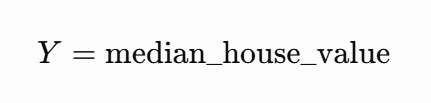

Y = es la variable de la que ya tenemos valores pero que queremos predecir y las otras variables son predictoras como X1 = longitude, X2 = Latitude y así con las demás.

La variable Y de predicción es algo así:
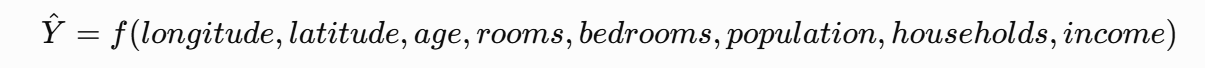

Y = Valor Real
/ Y (Techito) = Valor Predicho

## 1.3 Carga del Dataset y Separación del conjunto de prueba

In [22]:
datatest = pd.read_csv('/content/sample_data/california_housing_test.csv', sep = ",") # Carga del dataset
datatest.sample(5) # Monstrar datos e inspeccionarlos

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
877,-118.41,33.97,44.0,2789.0,503.0,3732.0,474.0,4.6176,352300.0
1589,-121.29,38.68,20.0,1881.0,378.0,921.0,360.0,1.8589,144000.0
2596,-118.31,34.06,36.0,369.0,147.0,145.0,136.0,0.8804,450000.0
2340,-117.68,33.65,6.0,10395.0,1915.0,4783.0,1811.0,5.9280,239900.0
635,-122.56,37.90,36.0,1760.0,283.0,562.0,246.0,6.7546,402400.0


Es importante saber que ambas cargas son dataset distintos porque Google Colab ya proporciona este ejemplo con archiivos diferentes de California Housing.

No es necesario utilizar train_test_split() para hacer la sepación inicial. Los datos ya vienen separados.


In [23]:
print("Tamaño de datos entrenamiento", datatrain.shape)
print("Tamaño de datos de prueba", datatest.shape)

Tamaño de datos entrenamiento (17000, 9)
Tamaño de datos de prueba (3000, 9)


Hay 17.000 observaciones para el entrenamiento (85% del Universo de Datos para Train) y 3.000 observaciones para prueba (15% del Universo de Datos para Test).

## 2. Conjunto de Entrenamientos, Validación y Prueba & Validación-Cruzada

En cualquier problema ML lo recomendable es trabajar con una triple partición del universo de datos: Entrenamiento, Validación y Prueba.

No necesariamente se tiene que crear físicamente tres archivos diferentes, ya se tienen 17.000 observaciones en Train que es donde se crearan temporalmente las particiones de validación mediante **Validación Cruzada**.

# 3. Transformaciones durante el Preprocesamiento

Antes de entrenar primero hay que conocer los datos.

**Pipeline:** Tubería, facilita y automatiza el proceso de limpiado y preparación de los datos.

* Imputación
* Transformaciones de distribución
* Normalización o estandarización

In [24]:
datatrain.info() # 1. Comprueba los tipos de datos
                  # 2. Comprueba Valores Faltantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [25]:
sns.set(rc={'figure.figsize':(10,12)})

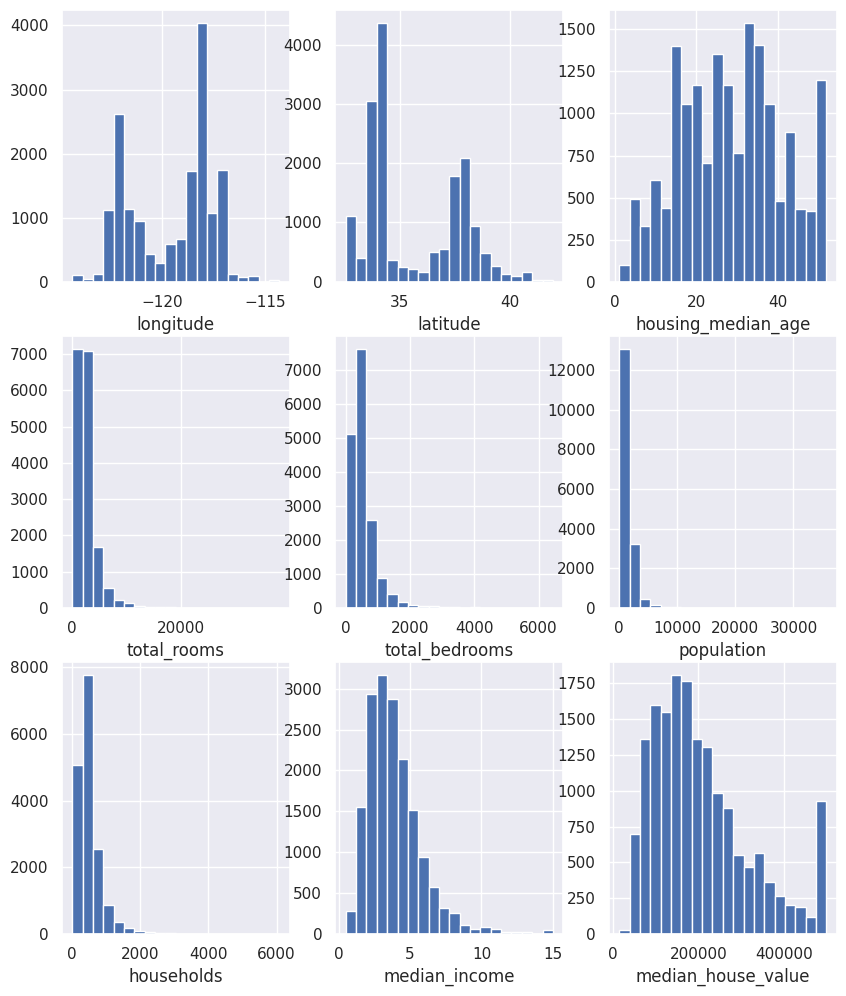

In [26]:
fig, axes = plt.subplots(3, 3)    # Definimos una ventana de 3x3 nichos para incluir en cada uno de ellos un gráfico.
for k in range(0,9): # El "for" es un bucle y se usar para repetir el procedimiento de crear un histograma para cada columna
  plt.subplot(3,3,k+1)     # Los nichos para cada histograma se numeran iniciando en 1.
  plt.hist(datatrain[datatrain.columns[k]], bins=20)     # datatrain.columns nos devuelve una lista con los nombres de las columnas.
  plt.xlabel(datatrain.columns[k])
plt.show()

Se construye un hsitograma para cada variable.

Aquí **k** toma sucesivamente de 0 a 8 y datatrain.columns[k] va seleccionando cada columna entonces cuando k = 0 toma longitude y así sucesivamente.

plt.hist(...) evita escribir nueve veces.

Lo que se intenta descubir con los histogramas es la distribución de las variables y como se puede observar algunas tienen un **sesgo positivo**, por ejemplo: total_rooms, total_bedrooms, population, households, median_income. Estos tienen muchos valores relativamente pequeños y algunos valores extredamente grandes.

**¿Por qué puede importarle esto a Machine Learning?**
Particularmente en modelos lineales y técnicas estadísticas, pueden comportarse mejor cuando determinadas variables tienen distribuciones menos extremadamente sesgadas.
La idea es probar transformaciones para reducir esa asimetría.

In [27]:
datatrain.describe() # Calculamos estadísticas descriptivas

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Se confirman los sesgos que graficamente se notan se ven en los histrogramas.

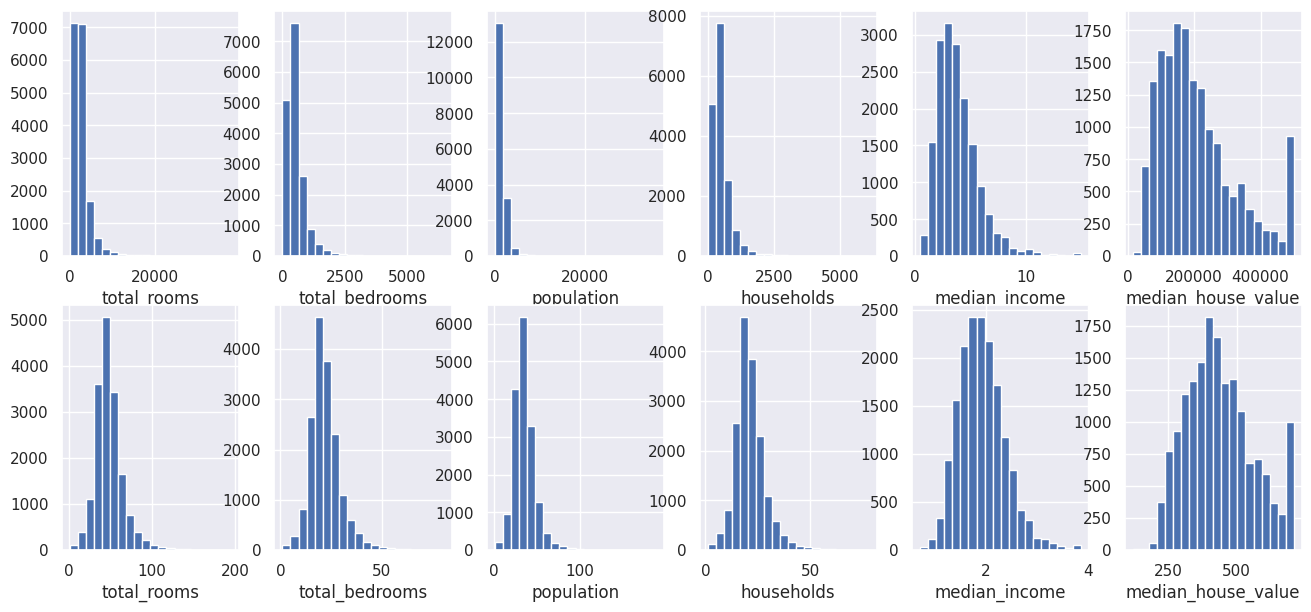

In [28]:
sns.set(rc={'figure.figsize':(16,7)})

fig, axes = plt.subplots(2, 6)
for k in range(3,9):             # grafiquemos por el momento solo los factores con marcado sesgo positivo.
  plt.subplot(2,6,k-2)

  tmp = datatrain[datatrain.columns[k]]   # datos originales.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

  plt.subplot(2,6,k+4)
  tmp = np.sqrt(datatrain[datatrain.columns[k]])   # Se aplica raiz cuadrada / datos con alguna transformación para ajuste de la distribución.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

plt.show()

La transformación es la siguiente:
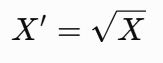

La diferencia relativa se reduce, la transformación puede hacer que una variable que este extremadamente inclinada hacia la derecha, tenga una distribución menos asimétrica.

## 4. Métricas de desempeño

Una vez ya entrenado el modelo, se debe seleccionar una métrica para que nos diga qué tan bien en promedio se están llevando a cabo las predicciones en los datos de validación y prueba.

La manera general en la que funcionan esas métricas es midiendo qué tan diferente en promedio son las predicciones hechas con el modelo entrenado.
Es decir, las predicciones con respecto a los valores observados reales.

En un problema de "Regresión" la diferencia entre las predicciones y los valores observados reales se le llama error o residuo que es calculado de la siguiente forma:

e = y - y (La diferencia entre las predicciones y el valor real) A los valores reales le vamos a restar las predicciones.

Existen una gran variedad de métricas.

In [29]:
# Definimos nuestra función del coeficiente de determinación ajustado a partir de las fórmulas dadas anteriormente, donde:
#   y_true: valores observados reales
#   y_hat : predicciones

# Suma de cuadrados de los errores
def mi_SSE(y_true, y_hat): # def = define una función
                            # mi_SSE = se nombra la función
                            # Recibe y_true valores verdaderos y y_hat predicciones
  return sum( np.square(y_true - y_hat)) # Acá se calculan los errores y np.square eleva al cuadrado los errores

# Suma de cuadrados de la variabilidad total:
def mi_Syy(y_true, y_hat):    # observa que se usa el valor promedio de las observaciones del conjunto de entrenamiento ymtrain.
  return sum( np.square(y_true - ymtrain))

# Coeficiente de determinación ajustado
def mi_R2adj(sse, syy, n, k):
  tmp = ((n-1) / (n-k-1)) * ((sse/syy))     # n: total de registros. k: total de variables independientes (predictores).
  return 1 - tmp    #coeficiente de determinación ajustado R2adj

Función mi_SSE

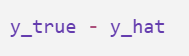 = 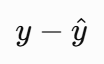

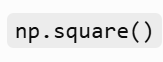 = 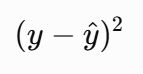

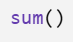 = 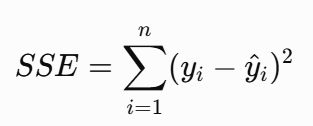

Función mi_Syy

Aunque está función recibe y_hat, realmente no lo utiliza, lo importante es ymtrain que representa la media del conjunto de entrenamiento:

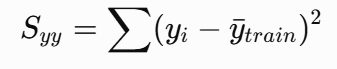

Está fórmula intenta medir la variabilidad de los valores reales respecto a una referencia basada en entrenamiento.

Función de R2 ajustado

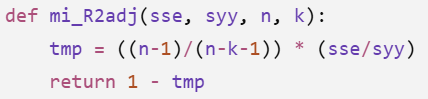 = 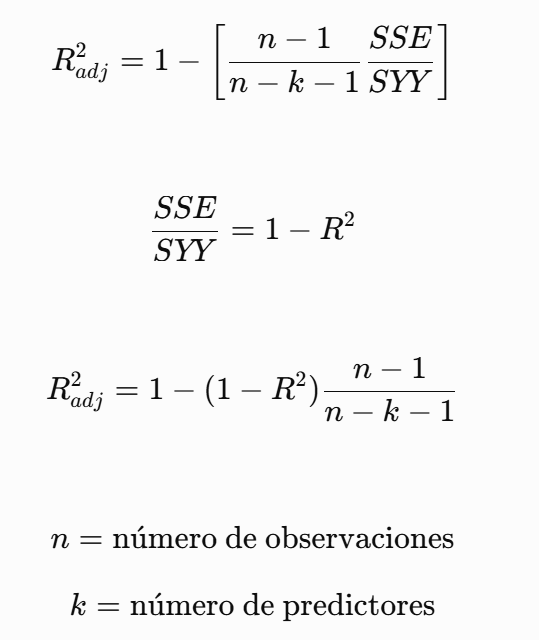

## 5. Conjuntando todos los pasos para el entrenamiento del modelo de Regresión Lineal Múltiple

In [30]:
# Librerías
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import KFold   # Particiones de Cross Validation

Vamos a separar las variables de entrada o variable de entrada y las de salida de los conjuntos de entrenamiento y prueba. Esto porque en la etapa de preprocemiento porque se le aplican trasnformaciones distintas a las variables.

In [31]:
# Con los datos de entrenamiento
# se generaran las particiones de Cross Validation,
# para eso hacemos lo siguiente:

# Separamos las variables X que utilizamos para predecir Y y de esas variables predictoras X, eliminamos nuestra Y
Xtrain = datatrain.drop('median_house_value', axis= 'columns')
ytrain = datatrain['median_house_value']

# Se hace lo mismo para los datos de prueba:
Xtest = datatest.drop('median_house_value', axis= 'columns')
ytest = datatest['median_house_value']

**Preprocesamiento**: ⌛

Vamos a imputar con el valor de la mediana, aunque no tenemos ningún valor pérdido, pero si deespués se encuentra vamos a dejarlo preparado.

Luego hacemos un escalamiento en un intervalo de 1 y 2.

A continuación, lo que se ve en código es un Pipeline:

In [32]:
# Escalamos e imputamos
num_prepro_pipeline = Pipeline(steps=[  ('imputar', SimpleImputer(strategy='median')), # Primer Paso: Imputación, si existe algún valor faltante sustituyelo por la mediana de esa variables
                                        ('escalar', MinMaxScaler(feature_range=(1,2)))]) # Segundo Paso: Escalamiento, esto escala las variables al intervalo [1,2]
num_prepo_nombre = list(Xtrain.columns)

# Transformar raiz cuadrada para las variables con sesgos
num_raiz_pipeline = Pipeline(steps=[  ('sqrt', FunctionTransformer(np.sqrt))]) # Aquí se crea otro Pipeline, saca raiz cuadrada de las variables predictoras
num_raiz_nombre = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Aplicamos las transformaciones a las variables indicadas
ColumnasTransformer = ColumnTransformer(transformers=[('num_prepro', num_prepro_pipeline, num_prepo_nombre),
                                                      ('num_raiz', num_raiz_pipeline, num_raiz_nombre)],
                                                        remainder = 'passthrough') # Si hay una columna que no está en esas listas, no cambies nada.

- No hay valores faltantes pero se imputa poque la idea es construir un Pipeline robusto. Si en el futuro aparace un dato faltante, el proceso ya sabe qué hacer.

- En el escalamiento evitar 0 puede ser últil para transformaciones como logaritmos y Box-Cox.

- Las variables a las que se le aplica la raiz cuadrada tienen sesgo positivo.

Con respecto:
Pipeline = responde a ¿Qué pasos quiero ejecutar secuencialmente?
ColumnTransformer = responde a ¿Qué transformación se quiere aplicar a qué columnas?

Del MinMaxScaler que se hizo de 1 a 2, conviene mucho cuando decidimos aplicar tansformaciones posteriores como raiz cuadrada, boxcox, log porque estás tres son muy sensibles a valores 0.



In [33]:
# Seleccionamos nuestro modelo de Machine Learning, en nuestro caso
# es Regresión Lineal Múltiple

modelo_LR = LinearRegression() # Esta línea lo que dice es "quiero utilizar el algoritmo de Regresión Lineal"

# Se crean listas para guardar el calculo de métricas de desempeño, es decir los resultados:
scoresR2Train = []
scoresR2Val = []
scoresmiR2Val = []
scoresmiR2adjVal = []
scoresRMSEVal = []

# Se crea el K-Fold / Inicializamos la Cross Validcation usando KFOLD con k = 5
k = 5
kf = KFold(n_splits=k, shuffle=True) # KFold nos ayuda a hacer la Cross Validation y shuffle hace que antes de hacer las particiones se revuelven los datos

Shuffle = True, mezcla los registros antes de crear los folds, de esa forma se evita que accidentalmente los primeros 3.400 registros tengan alguna característica sistematicamente distinta de los últimos.

Las particiiones siempre van a cambiar cuando se vuelva a ejecutar el notebook y por eso se puede usar random_state.

**Acá comienza la Validación Cruzada**

In [34]:
for train_index, val_index in kf.split(Xtrain): # Para cada una de las cinco particiones, dame cuáles registros utilizaré para entrenamiento y cuáles para validación

  # Se construye Train y Validation dentro de cada fold:
  X_train, X_val = Xtrain.iloc[train_index], Xtrain.iloc[val_index]
  y_train, y_val = ytrain.iloc[train_index], ytrain.iloc[val_index]

  # Aplicamos las transformaciones al conjunto de entrenamiento
  XtrainFit = ColumnasTransformer.fit(X_train) # Aprende del conjunto de entrenamiento todo aquello que necesita aprender el preprocesamiento.
  X_trainTransf = XtrainFit.transform(X_train) # Aplicamos las transformaciones al conjunto de entrenamiento / Simplemente aplica las reglas aprendidas
  X_valTransf = XtrainFit.transform(X_val)  # utiliza exactamente las mismas reglas para transformar Validation
  ymtrain = y_train.mean() # Promedio de las observaciones del conjunto de entrenamiento, nos va a servir para calcular Syy

  # Generemos el modelo de regresión lineal con los datos de entrenamiento de cada partición
  modelo_LR = modelo_LR.fit(X_trainTransf, y_train) # Entrenamiento real del modelo
  scoresR2Train.append(modelo_LR.score(X_trainTransf, y_train)) # Guardamos los valores para calcular el R2 del conjunto de entrenamiento

  yhat = modelo_LR.predict(X_valTransf) # Predicciones del conjunto de validación / Usa el modelo entrenado para generar predicciones de Validation
  scoresR2Val.append(modelo_LR.score(X_valTransf, y_val)) # Guardamos los valores para calcular el R2 del conjunto de validación

  # Calcularemos el valor R2 de forma manual con nuestras fórmulas, con una pequeña filtración
  sse = mi_SSE(y_val, yhat)
  syy = mi_Syy(y_val, ymtrain) # esta función evita la filtración de información (Dataleake) al usar el promedio de los datos de entrenamiento
  scoresmiR2Val.append(1 - (sse/syy))

  # Calcular el R Ajustado:
  tmp = mi_R2adj(sse, syy, X_valTransf.shape[0], X_valTransf.shape[1])
  scoresmiR2adjVal.append(tmp)

  # Calcular el RMSE:
  ss = np.sqrt(mean_squared_error(y_val, yhat))
  scoresRMSEVal.append(ss)

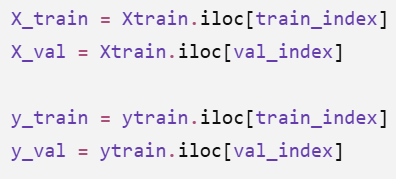

Ya existían Xtrain y ytrain que representan los 17.000 datos generales del entrenamiento, ahora X_Train y y_train representan el entrenamiento interno de un fold. Lo mismo con X_val y y_val. Xtest sigue completamente aparte.

La diferencia entre fit() y transform()

fit() es aprender y transforma() aplicar lo aprendido

Dataleake o filtración de información: Esto ocurre cuando se usa información del conjunto de validación o prueba para calcular estadísticas de entrenamiento.

Como se puede ver anteriormente en valiación se está usando el promedio de entrenamiento, si se usara el promedio de validación sezgaríamos la métrica o su proceso.

/tmp/ipykernel_1861/1474468515.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True, vert=False)


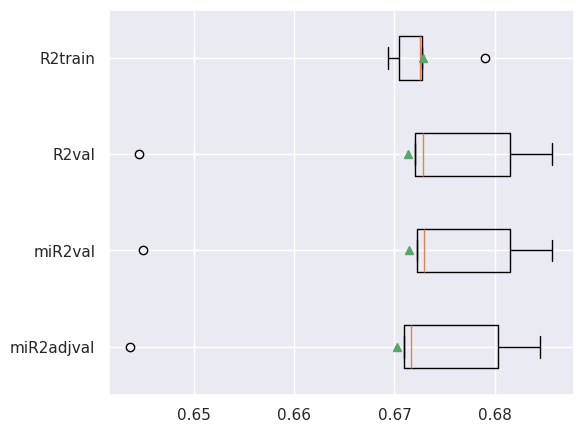

In [35]:
# Mostremos los diagramas de caja de los resultados obtenidos:
results = [scoresmiR2adjVal, scoresmiR2Val, scoresR2Val, scoresR2Train]
names = ['miR2adjval','miR2val','R2val','R2train']

sns.set(rc={'figure.figsize':(6,5)})
plt.boxplot(results, labels=names, showmeans=True, vert=False)
plt.show()

Es normal que en entrenamiento y validación de cosas diferentes porque son datos diferentes.

Es más amplio en R2val porque son menos datos.

In [36]:
# Despleguemos los resultados de los diferentes coeficientes de determinación obtenidos:

print("\t %s \t%s    \t%s  \t%s" % (names[3], names[2], names[1], names[0]))

for i,z in enumerate(zip(scoresR2Train, scoresR2Val, scoresmiR2Val, scoresmiR2adjVal)):
  print("fold[%d]:  %.4f \t%.4f  \t%.4f  \t%.4f" % (i+1,z[0],z[1],z[2],z[3]))

print("mean(std) %.3f(%.3f) %.3f(%.3f) %.3f(%.3f) %.3f(%.3f)" % (np.mean(scoresR2Train), np.std(scoresR2Train),
                                                                  np.mean(scoresR2Val), np.std(scoresR2Val),
                                                                  np.mean(scoresmiR2Val), np.std(scoresmiR2Val),
                                                                  np.mean(scoresmiR2adjVal), np.std(scoresmiR2adjVal)))

	 R2train 	R2val    	miR2val  	miR2adjval
fold[1]:  0.6726 	0.6729  	0.6729  	0.6717
fold[2]:  0.6693 	0.6857  	0.6857  	0.6845
fold[3]:  0.6790 	0.6446  	0.6450  	0.6436
fold[4]:  0.6727 	0.6720  	0.6722  	0.6710
fold[5]:  0.6705 	0.6815  	0.6815  	0.6803
mean(std) 0.673(0.003) 0.671(0.014) 0.671(0.014) 0.670(0.014)


In [37]:
# Y ahora desplegamos los valores de RMSE de validación de cada partición:

print("\t RMSEval")

for i,s in enumerate(scoresRMSEVal):
  print("fold[%d]:  %.2f" % (i+1,s))

print("mean(std) %.3f(%.3f)" % (np.mean(scoresRMSEVal), np.std(scoresRMSEVal)))

	 RMSEval
fold[1]:  66221.23
fold[2]:  65330.83
fold[3]:  67920.00
fold[4]:  67507.41
fold[5]:  65277.95
mean(std) 66451.486(1091.565)


## 6. Modelo Final, conjunto test y conclusiones

Suponamos que ya estamos satisfechos con el modelo, en este caso no es así pero supongamos, entonces ahora revisamos el conjunto de prueba.

In [38]:
# Inicializamos de nuevo nuestro mejor modelo con sus parámetros predeterminados:

modelo_LRf = LinearRegression()


# Ajustamos las transformaciones con el conjunto de "entrenamiento aumentado", i.e., el train-set
# completo del archivo inicial, pero con los MISMOS PASOS que ya se decidieron en la etapa de entrenamiento previa:

XtrainTf = ColumnasTransformer.fit(Xtrain)
XtrainFTf = XtrainTf.transform(Xtrain)    # Aplicamos las mejores transformaciones a los datos completos de train.
XtestFTf = XtrainTf.transform(Xtest)      # Aplicamos las transformaciones a Test con la información de Train para evitar la filtración.
                                          # Observa que esta es la primera vez que usamos los datos de prueba (Test) desde que iniciamos.


modelo_LRf = modelo_LRf.fit(XtrainFTf, ytrain)   # Entrenamos el mejor modelo con el conjunto de "entrenamiento aumentado".

yhatf = modelo_LRf.predict(XtestFTf)    # Generamos las predicciones con los datos de prueba (Test).

ymtrainf = np.mean(ytrain)     # Obtenemos el promedio de los datos de entrenamiento (recuerda que sklearn no nos regresa R2adj).

ssef = mi_SSE(ytest, yhatf)
syyf = mi_Syy(ytest, ymtrainf)

miR2adjf = mi_R2adj(ssef, syyf, XtestFTf.shape[0], XtestFTf.shape[1])  # Obtenemos R2adj con nuestra función que definimos previamente.

print("Métricas de desempeño del modelo final obtenido con el conjunto de prueba:")
print("Coeficiente de determinación ajustado: miR2adj = %.4f" % miR2adjf)

RMSEtestf = np.sqrt(mean_squared_error(ytest, yhatf))
print("Raiz del error cuadrático medio: RMSE = %.2f" % RMSEtestf)

Métricas de desempeño del modelo final obtenido con el conjunto de prueba:
Coeficiente de determinación ajustado: miR2adj = 0.6396
Raiz del error cuadrático medio: RMSE = 67756.78


El modelo aprendió bien porque da muy parecido el error.

Pero hay que mejorar el modelo.

El 0.63 es la variabilidad que se puede explicar, el resto no se puede explicar.

Verbos de Scikit-Learn:

.fit() = Aprender

.transform() = aplicar una transformación que ya apredió

.predict() = producir predicciones

.score() = calcula una métrica de desempeños determinada por el estimador


X = Siempre significa las variables predictoras

y = Representa la variable objetivo

y(techito) = Representa la predicción